<center><b>Python Programming for Multilingual Text</b></center>
<center>2-5: Text Analysis with the Montagu Corpus</center>

---

# Text Analysis with the Montagu Corpus

## Overview

In the previous notebook we worked closely with a single letter — Letter 35 — to build up our text analysis toolkit from scratch. Now we scale up.

This notebook applies those same tools to the entire Montagu corpus and introduces a few new ones:

1. **Setup**: load the corpus into a DataFrame, recap tools from 2-4
2. **Corpus-level counts**: word counts and sentence counts across all letters
3. **Word frequency**: most common words, stopword filtering, frequency plots
4. **Bigrams**: pairs of words that travel together
5. **POS tagging**: assigning grammatical categories, extracting adjectives and nouns
6. **Lemmatization**: collapsing inflected forms into a base form using POS tags

---

**Dataset:** Lady Mary Wortley Montagu's *Turkish Embassy Letters* (1716–1718)

---
## Step 1: Setup

In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag, FreqDist
from nltk.stem import WordNetLemmatizer

import string
from itertools import chain

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# Load the corpus
montagu = pd.read_csv('../../output/montagu_letters_v2.csv')
montagu.head()

,filename,references,title,addressee,location,date_original,date_edited,body,notes
0,letter_1.txt,broadview_47-48,﻿LETTER 1.,TO THE COUNTESS OF ----.,_Rotterdam,Aug_. 3. O. S. 1716.,1716-08-03,"I FLATTER, myself, dear sister, that I shall g...",NaN
1,letter_2.txt,broadview_48-49,LET. II,TO MRS. S----.,_Hague,Aug. 5_. O. S. 1716.,1716-08-05,"I MAKE haste to tell you, dear Madam, that, af...",NaN
2,letter_3.txt,broadview_49-50,LET. III,TO MRS. S. C.,_Nimeguen,Aug_.13. O. S. 1716.,1716-08-13,"I AM extremely sorry, my dear S. that your fea...",NaN
3,letter_4.txt,broadview_50-51,LET. IV.,TO THE LADY ----.,_Cologn (sic),"Aug_, 16. O. S. 1716.",1716-08-16,IF my lady ---- could have any notion of the ...,NaN
4,letter_5.txt,broadview_51-53,LET. V.,TO THE COUNTESS OF B----.,_Nuremberg,Aug_. 22. O. S. 1716.,1716-08-22,"AFTER five days travelling post, I could not s...",NaN


> ⚠️ **Two common errors before data loads:**
> - `NameError` — you forgot to `import pandas as pd`
> - `FileNotFoundError` — the path to your file is wrong

### Some quick checks

In [ ]:
# Remember this from 2-5_pandas?
montagu.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   filename       52 non-null     str  
 1   references     52 non-null     str  
 2   title          52 non-null     str  
 3   addressee      52 non-null     str  
 4   location       50 non-null     str  
 5   date_original  50 non-null     str  
 6   date_edited    52 non-null     str  
 7   body           52 non-null     str  
 8   notes          2 non-null      str  
dtypes: str(9)
memory usage: 3.8 KB


> Do we need all of these columns? For the purposes of this exercise, we will only keep 'filename', 'title', and 'body

In [ ]:
### YOUR CODE HERE

In [3]:
# This is how I would do it

montagu = montagu[['filename', 'title', 'body']]
print()
montagu.head()

,filename,title,body
0,letter_1.txt,﻿LETTER 1.,"I FLATTER, myself, dear sister, that I shall g..."
1,letter_2.txt,LET. II,"I MAKE haste to tell you, dear Madam, that, af..."
2,letter_3.txt,LET. III,"I AM extremely sorry, my dear S. that your fea..."
3,letter_4.txt,LET. IV.,IF my lady ---- could have any notion of the ...
4,letter_5.txt,LET. V.,"AFTER five days travelling post, I could not s..."


### Recap: what we have in each letter

In notebook 2-4 we worked with Letter 35 in isolation. Let's pull it back out and confirm our tools still work before scaling up.

In [9]:
letter_35 = montagu['body'].iloc[34]
letter_35_words = [word.strip(string.punctuation).lower() for word in letter_35.split()]
letter_35_words_no_stop = [w for w in letter_35_words if w not in stop_words]

print(f"Total words: {len(letter_35_words)}")
print(f"After stopword removal: {len(letter_35_words_no_stop)}")
print(f"Most common: {Counter(letter_35_words_no_stop).most_common(5)}")

Total words: 1799
After stopword removal: 796
Most common: [('one', 9), ('little', 7), ('great', 6), ('tis', 6), ('fine', 5)]


Here are our findings from notebook 2-4:

* Number of words in letter 35: 1799 words
* Number of words in letter 35 after text normalization and stopword removal: 796
* [('one', 9),
 ('little', 7),
 ('great', 6),
 ('tis', 6),
 ('fine', 5),
 ('night', 5),
 ('good', 5),
 ('greek', 5),
 ('upon', 5),
 ('women', 4)]

> P.S.: if you do not remember where exactly we got this output, it's ok! and it might be a sign that you need to go back and take another look at that notebook

Good — same results as before. Now let's apply this to all 58 letters.

`OR`

Well, that is a lot of code for one tiny cell. Let's unpack this together.

```python
letter_35 = montagu['body'].iloc[34]
```

Instead of reading letter_35 from the text file like we did in 2-4, we extract it from the dataframe. 

`montagu['body']` -> let's us choose the body column in our montagu df

`.iloc[34]` -> let's us get the 34th row in that column, which is letter 35 because our rows are 0-indexed.

In a bit more technical terms: we assign the contents of the cell in row: 34, column: body of our montagu df to the variable `letter_35`

We expect this to be a string, which would allow us to do the transformations in the next two lines

In [11]:
# It is indeed a string

type(letter_35)

str

```python
letter_35_words = [word.strip(string.punctuation).lower() for word in letter_35.split()]
```

This is a list comprehension (see 2-2_iterations) which allows us to create a list `letter_35_words` by transforming `letter_35`. We need to start reading this from the end:

`letter_35.split()` -> creates a list of strings from `letter_35` by splitting it by whitespace (see 1-6_data-structure and 2-4)

`for word in letter_35.split()` -> this is basically the for-loop, where we are iterating over each word, to do something

`word.strip(string.punctuation).lower()` -> this is what we are doing to each word:

- `string.punctuation` -> gives us a list of punctuation marks
- `word.strip(string.punctuation)` -> removes punctuation from the **start and end** of each word
- `.lower()` lowercases the word that has now been stripped of punctuation


```python
letter_35_words_no_stop = [w for w in letter_35_words if w not in stop_words]
```

Anther list comprehension! Another list comprehension! In plain terms: go through every word (`w`) in `letter_35_words`, and keep it only if it is not in our stopword list.


---
## Step 2: Corpus-level counts

In notebook 2-4 we computed word and sentence counts for a single letter by hand. With a DataFrame, we can do this for all letters at once using `.apply()`.

`.apply()` takes a function and runs it on every row (or every value in a column). The `lambda` keyword lets us write that function inline without naming it.

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  Let's start by counting the words and sentences in Montagu's letters
</div>

Before we apply the lambda, we will break down the task

In [5]:
# let's take one letter as an example
example = montagu['body'].iloc[0]
print(example[:200])

I FLATTER, myself, dear sister, that I shall give you some pleasure
in letting you know that I have safely passed the sea, though we had
the ill fortune of a storm.  We were persuaded by the captain o


In [6]:
# word_tokenize splits it into tokens
tokens = word_tokenize(example)
print(tokens[:20])

['I', 'FLATTER', ',', 'myself', ',', 'dear', 'sister', ',', 'that', 'I', 'shall', 'give', 'you', 'some', 'pleasure', 'in', 'letting', 'you', 'know', 'that']


> Can you spot the difference between `.split()` and `word_tokenize(str)`?

`.split()` is a basic Python string method that cuts the text wherever it sees whitespace. 

Remember our brief discussion on tokenization? We said that for the purposes of this workshop, we were talking about tokenization as splitting longer texts into words = tokens. We used `.split()` as a tokenizer because whitespace indicates word boundary in English, so splitting by whitespace splits texts into words.

`word_tokenize()` is more complex. It is an NLTK tokenizer trained to treat punctuation as separate tokens. So `"they'll"` becomes `["they", "'ll"]` with `word_tokenize()`, but stays as `["they'll"]` with `.split()`. For counting words, this distinction matters.

In [17]:
print(word_tokenize("they'll join us."))

['they', "'ll", 'join', 'us', '.']


In [16]:
print("they'll join us.".split())

["they'll", 'join', 'us.']


In [ ]:
# let's see this side by side with our first letter
print(example[:100].split())
print(word_tokenize(example[:100]))

['I', 'FLATTER,', 'myself,', 'dear', 'sister,', 'that', 'I', 'shall', 'give', 'you', 'some', 'pleasure', 'in', 'letting', 'you', 'know', 'that', 'I', 'have']
['I', 'FLATTER', ',', 'myself', ',', 'dear', 'sister', ',', 'that', 'I', 'shall', 'give', 'you', 'some', 'pleasure', 'in', 'letting', 'you', 'know', 'that', 'I', 'have']


This difference also has a downstream impact on word counts

In [7]:
# We can count our words like this:
print(len(tokens))

633


In [19]:
# but it is not the same as this
print(len(example.split()))

553


From 633 words with `word_tokenize()` to 553 with `.split()`! 80 words is a big difference in such a short text/small corpus.

Not all additional words are punctuation. As we have seen above, `they'll` is split to its original parts: `they` and `'ll`, so it is supposed to be two words. Word tokenization is more refined than splitting by whitespace.

*But here is the deal:* what we will do next, will **remove all words that are not alphabetical** for counting purposes. This also includes `'ll`. We could come up with rule based exceptions like if the character is `'` or `-` keep it and we could even use regex for this (check out the notebook 2-6_regular_expressions!) But all of that is too finicky in the grand scheme of things. The real solution to this problem will come later in this notebook, when we get to POS tagging, where contractions are handled more gracefully.



`.isalpha()` is a string method that returns True only for strings made entirely of letters or alphabetic characters, which filters out punctuation tokens, numbers, and anything else that isn't in the [Unicode](https://en.wikipedia.org/wiki/Unicode) alphabet

In [1]:
print("Constantinople".isalpha())  # English
print("القاهرة".isalpha())          # Arabic
print("北京".isalpha())              # Chinese
print("Κωνσταντινούπολη".isalpha()) # Greek
print("123".isalpha())              # number — False
print("they'll".isalpha())          # apostrophe — False

True
True
True
True
False
False


In [8]:
# let's see it in action
tokens = [t for t in tokens if t.isalpha()]
print(len(tokens))
print(tokens[:50])

548
['I', 'FLATTER', 'myself', 'dear', 'sister', 'that', 'I', 'shall', 'give', 'you', 'some', 'pleasure', 'in', 'letting', 'you', 'know', 'that', 'I', 'have', 'safely', 'passed', 'the', 'sea', 'though', 'we', 'had', 'the', 'ill', 'fortune', 'of', 'a', 'storm', 'We', 'were', 'persuaded', 'by', 'the', 'captain', 'of', 'the', 'yacht', 'to', 'set', 'out', 'in', 'a', 'calm', 'and', 'he', 'pretended']


Now we have 548 words!

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  Let's apply this transformation to all letters and save the word counts
</div>

In [4]:
# Word count per letter using NLTK's word_tokenize
montagu['word_count'] = montagu['body'].apply(
    lambda text: len([t for t in word_tokenize(text) if t.isalpha()])
)

In [5]:
montagu.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    52 non-null     str  
 1   title       52 non-null     str  
 2   body        52 non-null     str  
 3   word_count  52 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [11]:
montagu.head()

,filename,title,body,word_count
0,letter_1.txt,﻿LETTER 1.,"I FLATTER, myself, dear sister, that I shall g...",548
1,letter_2.txt,LET. II,"I MAKE haste to tell you, dear Madam, that, af...",290
2,letter_3.txt,LET. III,"I AM extremely sorry, my dear S. that your fea...",489
3,letter_4.txt,LET. IV.,IF my lady ---- could have any notion of the ...,483
4,letter_5.txt,LET. V.,"AFTER five days travelling post, I could not s...",647


Let's unpack this code:
```python
montagu['word_count'] = montagu['body'].apply(
    lambda text: len([t for t in word_tokenize(text) if t.isalpha()])
)
```

`montagu['word_count']` -> creates a new column in our df called 'word_count'

`montagu['body']` -> this is the column we operate on

`.apply(lambda text: len([t for t in word_tokenize(text) if t.isalpha()]))` -> this is the operation

- `.apply()` is how we apply a function to every row in our body column
- `lambda` is the keyword lets us write that function inline without naming it.
- `text` is the placeholder name for each letter body as `.apply()` passes it in one by one
- `word_tokenize(text)` splits the letter into tokens
- `t.isalpha()` keeps only tokens made entirely of letters
- `len()` counts what's left 

> We will do the same process with sentences in all letters. We already looked at splitting sentences in notebook 2-4. We covered how lambda and apply work. This is the part of coding where you have to trust your code

In [6]:
# Sentence count per letter
montagu['sentence_count'] = montagu['body'].apply(lambda text: len(sent_tokenize(text)))

In [8]:
montagu[['title', 'word_count', 'sentence_count']].head()

,title,word_count,sentence_count
0,﻿LETTER 1.,548,18
1,LET. II,290,12
2,LET. III,489,18
3,LET. IV.,483,12
4,LET. V.,647,18


In [7]:
# Let's double check that everything went the way we wanted it to
# From 2-4 -> Number of sentences in letter 35: 68

num_expected = 68

num = int(montagu.loc[34, 'sentence_count'])

if num == num_expected:
    print("All good")

All good


In [9]:
# Summary statistics for both
montagu[['word_count', 'sentence_count']].describe().round(1)

,word_count,sentence_count
count,52.0,52.0
mean,1138.4,49.6
std,749.9,88.1
min,146.0,3.0
25%,595.0,18.8
50%,897.0,28.0
75%,1493.5,49.2
max,3558.0,637.0


<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  What does the standard deviation tell us here? What does it say about Lady Montagu's writing habits?
</div>

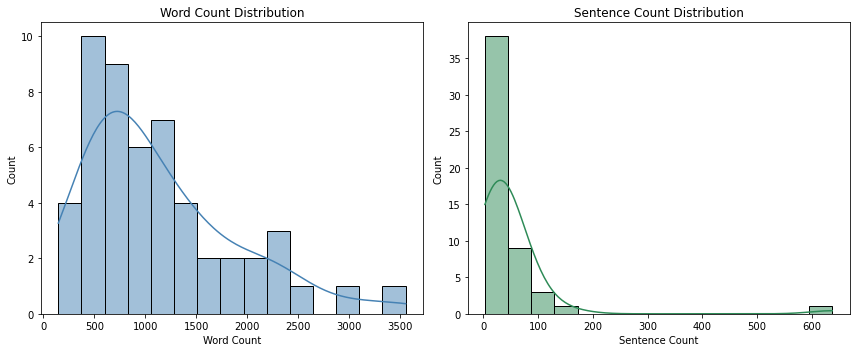

In [10]:
# Visualize the distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(montagu['word_count'], kde=True, color='steelblue', bins=15, ax=axes[0])
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Word Count')

sns.histplot(montagu['sentence_count'], kde=True, color='seagreen', bins=15, ax=axes[1])
axes[1].set_title('Sentence Count Distribution')
axes[1].set_xlabel('Sentence Count')

plt.tight_layout()
plt.show()

In [11]:
# Which are the longest and shortest letters?
print("Longest letter:")
print(montagu.loc[montagu['word_count'].idxmax(), ['title', 'word_count']])

print("\nShortest letter:")
print(montagu.loc[montagu['word_count'].idxmin(), ['title', 'word_count']])

Longest letter:
title         LET. XLIV.
word_count          3558
Name: 43, dtype: object

Shortest letter:
title         LET. XVI.
word_count          146
Name: 15, dtype: object


---
## Step 3: Word Frequency across the corpus

In 2-4 we counted words in a single letter. Now let's pool all 58 letters into one token list and ask: what does Montagu talk about most?

In [ ]:
# Join all letter bodies into one big string, then tokenize
all_text = ' '.join(montagu['body'].tolist())
all_tokens = word_tokenize(all_text)

print(f"Total tokens across all letters: {len(all_tokens)}")

In [ ]:
# Clean: lowercase, alphabetic only, remove stopwords
filtered_tokens = [
    word.lower() for word in all_tokens
    if word.lower() not in stop_words and word.isalpha()
]

print(f"Tokens after filtering: {len(filtered_tokens)}")
print(f"Unique tokens: {len(set(filtered_tokens))}")

We are using a list comprehension here — a compact way to write a for-loop that builds a list. Here is the same thing written as a regular loop so you can compare:

```python
filtered_tokens = []
for word in all_tokens:
    if word.lower() not in stop_words and word.isalpha():
        filtered_tokens.append(word.lower())
```

Both produce exactly the same result.

In [ ]:
# Frequency distribution using NLTK's FreqDist
freq_dist = FreqDist(filtered_tokens)

print("Top 20 most common words:")
freq_dist.most_common(20)

In [ ]:
# Plot the top 30 words
plt.figure(figsize=(12, 5))
freq_dist.plot(30, cumulative=False)
plt.xticks(rotation=45)
plt.title('Top 30 Words in Montagu Letters')
plt.tight_layout()
plt.show()

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  What does this frequency distribution tell us about the content of the letters? What do you notice about the most frequent words that survived stopword removal?
</div>

---
## Step 4: Bigrams

Individual words can be ambiguous. "Grand" means something different in "grand tour" than in "grand piano." **Bigrams** — pairs of adjacent words — preserve some of that context.

Think of bigrams as a window of size 2 sliding across the text:

> `I have had the advantage` → `(I, have)`, `(have, had)`, `(had, the)`, `(the, advantage)` …

In [ ]:
from nltk.util import bigrams

bigram_freq = Counter()

for letter in montagu['body'].tolist():
    # tokenize, lowercase, keep only alphabetic tokens, remove stopwords
    tokens = [
        word.lower() for word in word_tokenize(letter)
        if word.isalpha() and word.lower() not in stop_words
    ]
    bigram_freq.update(bigrams(tokens))

print("Top 20 bigrams:")
for bigram, count in bigram_freq.most_common(20):
    print(f"{bigram[0]} {bigram[1]}: {count}")

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  These are personal letters — what do the most common bigrams reveal about the genre? Would you expect different bigrams in, say, a newspaper or a legal document?
</div>

---
## Step 5: POS Tagging

**Part-of-Speech (POS) tagging** assigns a grammatical category to each word — noun, verb, adjective, and so on. This is a key step in many NLP pipelines because it tells us not just *what* words appear, but *what role* they play in the sentence.

POS tags typically include:

| Tag | Category | Example |
|---|---|---|
| `NN` | Noun, singular | *city, bath, letter* |
| `NNS` | Noun, plural | *women, gardens, letters* |
| `NNP` | Proper noun, singular | *Constantinople, Montagu* |
| `VBD` | Verb, past tense | *visited, wrote, observed* |
| `JJ` | Adjective | *fine, curious, Turkish* |
| `RB` | Adverb | *very, much, quite* |
| `PRP` | Personal pronoun | *I, she, they* |
| `IN` | Preposition | *in, of, at* |

NLTK's `pos_tag()` takes a list of tokens and returns a list of `(word, tag)` tuples.

In [ ]:
# Let's start with Letter 35 again — one sentence
sentences = sent_tokenize(letter_35)
sample_sentence = sentences[0]
print(sample_sentence)

In [ ]:
# Apply POS tagging to the first sentence
pos_tags = pos_tag(word_tokenize(sample_sentence))
pos_tags

### Extracting adjectives

Adjectives can tell us a lot about tone and sentiment. Let's write a function to extract them.

Note that we use a simple heuristic to reduce false positives: we only keep a word tagged `JJ` if the *next* word is a noun (`NN`). This filters out cases where the tagger mislabels a word as an adjective.

In [ ]:
def extract_adjectives(text):
    """Extract adjectives that directly precede a noun."""
    tokens = word_tokenize(text.lower())
    tagged = pos_tag(tokens)
    adjectives = []
    for i in range(len(tagged) - 1):
        word, tag = tagged[i]
        next_word, next_tag = tagged[i + 1]
        if tag.startswith('JJ') and next_tag.startswith('NN'):
            adjectives.append(word)
    return adjectives

In [ ]:
# Test on Letter 35
letter_35_adjectives = extract_adjectives(letter_35)
print(f"Adjectives in Letter 35: {letter_35_adjectives}")

In [ ]:
# Apply to all letters and store in a new column
montagu['adjectives'] = montagu['body'].apply(extract_adjectives)
montagu[['title', 'adjectives']].head()

In [ ]:
# Flatten into one list and count
all_adjectives = list(chain.from_iterable(montagu['adjectives']))
adjective_counts = Counter(all_adjectives)

print("Top 15 adjectives across all letters:")
for adj, count in adjective_counts.most_common(15):
    print(f"  {adj}: {count}")

In [ ]:
# Visualize
top_adj = adjective_counts.most_common(20)
adjs, counts = zip(*top_adj)

plt.figure(figsize=(12, 5))
plt.bar(adjs, counts, color='steelblue')
plt.title('Most Common Adjectives in Montagu Letters')
plt.xlabel('Adjective')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Extracting nouns

While adjectives hint at sentiment and tone, **nouns** get us closer to the *topics* of the letters — the places, people, and things Montagu writes about.

Nouns in English come in several forms, each with their own POS tag:

- `NN` — singular common noun: *bath, letter, woman*
- `NNS` — plural common noun: *baths, letters, women*
- `NNP` — singular proper noun: *Constantinople, Adrianople*
- `NNPS` — plural proper noun: *Ottomans, Europeans*

In [ ]:
# First, get POS tags for all letters and store them
montagu['pos_tags'] = montagu['body'].apply(lambda x: pos_tag(word_tokenize(x)))

noun_tags = {'NN', 'NNS', 'NNP', 'NNPS'}

def extract_nouns(pos_tag_list):
    """Extract all nouns from a list of (word, tag) tuples."""
    return [word.lower() for word, tag in pos_tag_list
            if tag in noun_tags and word.isalpha() and len(word) > 2]

montagu['nouns'] = montagu['pos_tags'].apply(extract_nouns)
montagu[['title', 'nouns']].head()

In [ ]:
# Flatten and count
all_nouns = list(chain.from_iterable(montagu['nouns']))
noun_counts = Counter(all_nouns)

print("Top 15 nouns across all letters:")
for noun, count in noun_counts.most_common(15):
    print(f"  {noun}: {count}")

In [ ]:
# Visualize top 30 nouns
top_nouns = noun_counts.most_common(30)
nouns, counts = zip(*top_nouns)

plt.figure(figsize=(14, 6))
sns.barplot(x=list(nouns), y=list(counts), palette='viridis')
plt.title('Most Common Nouns in Montagu Letters')
plt.xlabel('Noun')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  Nouns tell a different story from adjectives. Compare the two charts — what does each one reveal about the letters that the other doesn't?
</div>

---
## Step 6: Lemmatization

Our noun and adjective counts work well, but they still treat inflected forms as separate words. For example:

- `woman` and `women` are counted separately
- `great`, `greater`, `greatest` are counted separately
- `observed`, `observing`, `observes` are counted separately

**Lemmatization** reduces each word to its **lemma** — the base dictionary form. This gives us a more accurate picture of the vocabulary.

It is different from **stemming** (which you may have heard of), which just chops off suffixes and can produce non-words like `observ`. Lemmatization produces real words.

| Word | Stemmed | Lemmatized |
|---|---|---|
| `women` | `women` | `woman` |
| `observed` | `observ` | `observe` |
| `greater` | `greater` | `great` |
| `ladies` | `ladi` | `lady` |

In [ ]:
lemmatizer = WordNetLemmatizer()

# Basic usage — defaults to treating the word as a noun
print(lemmatizer.lemmatize('women'))     # woman
print(lemmatizer.lemmatize('ladies'))    # lady
print(lemmatizer.lemmatize('observed'))  # observed — not right yet!

Notice that `observed` didn't lemmatize correctly. That's because the lemmatizer defaults to treating every word as a **noun**. `observed` is a verb, so we need to tell it that.

This is where POS tags become really useful — we already have them! We just need to convert the NLTK POS tag format (e.g. `VBD`) into the format WordNet understands (`v` for verb, `n` for noun, `a` for adjective, `r` for adverb).

In [ ]:
from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag):
    """Convert a Treebank POS tag to a WordNet POS tag."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default to noun

In [ ]:
# Now lemmatize correctly using the POS tag
print(lemmatizer.lemmatize('observed', get_wordnet_pos('VBD')))   # observe ✓
print(lemmatizer.lemmatize('greater',  get_wordnet_pos('JJR')))   # great ✓
print(lemmatizer.lemmatize('ladies',   get_wordnet_pos('NNS')))   # lady ✓
print(lemmatizer.lemmatize('quickly',  get_wordnet_pos('RB')))    # quickly (already base form)

In [ ]:
def lemmatize_text(pos_tag_list):
    """Lemmatize all words in a (word, tag) list, skipping stopwords and punctuation."""
    return [
        lemmatizer.lemmatize(word.lower(), get_wordnet_pos(tag))
        for word, tag in pos_tag_list
        if word.isalpha() and word.lower() not in stop_words
    ]

# Apply to all letters — we already have pos_tags stored!
montagu['lemmas'] = montagu['pos_tags'].apply(lemmatize_text)
montagu[['title', 'lemmas']].head()

In [ ]:
# Compare raw tokens vs lemmas for Letter 35
raw_counts = Counter(filtered_tokens)  # from Step 3
lemma_counts = Counter(list(chain.from_iterable(montagu['lemmas'])))

print("Raw token counts (top 15):")
for word, count in raw_counts.most_common(15):
    print(f"  {word}: {count}")

print("\nLemma counts (top 15):")
for word, count in lemma_counts.most_common(15):
    print(f"  {word}: {count}")

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  Compare the two lists. Which words changed rank after lemmatization? Can you spot any cases where different inflected forms have been merged together?
</div>

In [ ]:
# A concrete example: how does lemmatization affect the noun 'woman'?
print("'woman' in raw tokens:", raw_counts.get('woman', 0))
print("'women' in raw tokens:", raw_counts.get('women', 0))
print("'woman' after lemmatization:", lemma_counts.get('woman', 0))

### A note on lemmatization for multilingual text

NLTK's `WordNetLemmatizer` only works for **English**. For other languages you need different tools:

- **spaCy** has lemmatizers for many languages (French, German, Spanish, Arabic, Chinese, and more)
- **Stanza** (from Stanford NLP) supports 70+ languages
- **TreeTagger** is a widely used tool especially in historical linguistics

The *concept* of lemmatization is the same across languages — reduce a word to its dictionary form — but what that means varies. In highly inflected languages like Arabic or Turkish, lemmatization collapses far more forms than in English, making it an even more important preprocessing step.

---
## Save your work

In [ ]:
# Save the enriched DataFrame
montagu.to_csv('montagu_letters_v3.csv', index=False)
print("Saved! Columns now:", montagu.columns.tolist())

---
## Summary

| What we did | Tool | New column |
|---|---|---|
| Count words per letter | `word_tokenize` + `.apply()` | `word_count` |
| Count sentences per letter | `sent_tokenize` + `.apply()` | `sentence_count` |
| Corpus-wide word frequency | `FreqDist` | — |
| Word pairs | `nltk.bigrams` | — |
| Grammatical categories | `pos_tag` | `pos_tags` |
| Adjectives preceding nouns | custom function | `adjectives` |
| Nouns (all forms) | custom function | `nouns` |
| Base dictionary forms | `WordNetLemmatizer` | `lemmas` |

In the next notebook we will use these enriched columns for **Named Entity Recognition (NER)** — identifying the people, places, and organisations Montagu mentions by name.